<a href="https://colab.research.google.com/github/saraalkhaldi98/5505DL-project/blob/main/Copy_of_CS552J_Assessment2_LastName_Firstname_studentNumber2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS552J — Human activity classification (MSCOCO subset)

## Sections

1. **Phase A** — Data Preprocessing: (Data preparation, Image loading, Base pipeline)
2. **Phase B** — Subtasks:
 - **Subtask 1** — `FNN_base` vs `CNN_base`  
 - **Subtask 2** — `CNN_gen` (augmentation + regularization)  
 - **Subtask 3** — Hugging Face transfer learning, **binary** classifier (two classes)  
 - **Subtask 4** — CLIP image embeddings + small classifier  
 - **Subtask 5** — CLIP cosine similarity / text–image features  
3. **Summary** — Results table

Install dependencies once: `pip install -r requirements.txt`


## **Phase A** — Data Preprocessing:
1- Data preparation:
- Load the subset CSV
- Download images from coco_url into a1_images/ (filename from URL / file_name).
- Map string label → integer with LABEL2ID (sorted unique labels).
- Build train/val indices with stratified 80/20 split.

2- Image loading (ImagePathDataset):
- Open file with PIL, .convert("RGB") so channels are consistent.

3- Base pipeline (base_tf) — used for FNN/CNN baseline and validation
- Resize((224, 224)) — fixed size for the network.
- ToTensor() — PIL → float tensor ([C,H,W]) in ([0,1]).
- Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) — ImageNet mean/std (standard for models pretrained on ImageNet-style data).


In [ ]:
# =============================================================================
# Setup: libraries, reproducible random seeds, device, and load the CSV index
# =============================================================================
import os
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=UserWarning)

# Same seed everywhere so splits, shuffles, and weight init match between runs
# (------------------------------------ don't forget to `pip freeze` before submission so others can reproduce versions)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# CSV lists COCO image URLs, filenames, and activity labels (one row per image)
df = pd.read_csv("cs552j_A1_dataset_image_id_url.csv")
# Some exports add a stray index column as the first column — drop if present
if str(df.columns[0]).startswith("Unnamed") or df.columns[0] == "":
    df = df.drop(columns=[df.columns[0]])
print(df["label"].value_counts())
print("Rows:", len(df))

Device: cpu
label
walking_running    98
sitting            95
standing           92
Name: count, dtype: int64
Rows: 285


In [ ]:
# All downloaded JPEGs go here; paths in later cells join this folder + file_name
save_folder = "a1_images"
os.makedirs(save_folder, exist_ok=True)

In [ ]:
def download_image(image_url, save_folder, skip_existing=True):
    """Download one image from a URL; filename is the last segment of the URL."""
    image_name = os.path.join(save_folder, image_url.split("/")[-1])
    # Skip re-download if we already have the file (safe to re-run this cell)
    if skip_existing and os.path.isfile(image_name):
        return image_name
    response = requests.get(image_url, timeout=60)
    if response.status_code == 200:
        with open(image_name, "wb") as file:
            file.write(response.content)
        print(f"Saved: {image_name}")
    else:
        print(f"Failed: {image_url}")
    return image_name

In [ ]:
# Run once (or again after failures); existing files are skipped automatically
for url in df.coco_url.values:
    download_image(url, save_folder, skip_existing=True)

Saved: a1_images/000000252219.jpg
Saved: a1_images/000000386912.jpg
Saved: a1_images/000000308394.jpg
Saved: a1_images/000000456496.jpg
Saved: a1_images/000000185250.jpg
Saved: a1_images/000000356427.jpg
Saved: a1_images/000000266409.jpg
Saved: a1_images/000000515579.jpg
Saved: a1_images/000000551215.jpg
Saved: a1_images/000000057597.jpg
Saved: a1_images/000000399462.jpg
Saved: a1_images/000000494869.jpg
Saved: a1_images/000000329219.jpg
Saved: a1_images/000000214720.jpg
Saved: a1_images/000000459153.jpg
Saved: a1_images/000000295713.jpg
Saved: a1_images/000000273132.jpg
Saved: a1_images/000000476415.jpg
Saved: a1_images/000000292082.jpg
Saved: a1_images/000000122046.jpg
Saved: a1_images/000000352684.jpg
Saved: a1_images/000000512836.jpg
Saved: a1_images/000000177015.jpg
Saved: a1_images/000000288042.jpg
Saved: a1_images/000000347265.jpg
Saved: a1_images/000000264535.jpg
Saved: a1_images/000000337055.jpg
Saved: a1_images/000000100624.jpg
Saved: a1_images/000000202228.jpg
Saved: a1_imag

In [ ]:
# --- Phase A: build file paths, encode labels, 80/20 stratified train/val split ---
# (Stratify keeps similar class proportions in train and validation.)

save_folder = "a1_images"
os.makedirs(save_folder, exist_ok=True)
IMG_SIZE = 224  # height and width after resize (matches common pretrained input sizes)
NUM_CLASSES = df["label"].nunique()
# Stable string -> int mapping (sorted label names so IDs don't shuffle if CSV order changes)
LABEL2ID = {lab: i for i, lab in enumerate(sorted(df["label"].unique()))}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
print("LABEL2ID:", LABEL2ID)


class ImagePathDataset(Dataset):
    """PyTorch Dataset: load image from disk path, apply optional torchvision transforms."""

    def __init__(self, paths, labels, transform=None):
        self.paths = list(paths)
        self.labels = list(labels)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        p = self.paths[idx]
        y = self.labels[idx]
        img = Image.open(p).convert("RGB")  # 3 channels even for grayscale files
        if self.transform:
            img = self.transform(img)
        return img, y


def build_path_label_arrays(frame):
    """Pair each CSV row with a local file under save_folder; skip rows with no file yet."""
    paths, labels = [], []
    missing = []
    for _, row in frame.iterrows():
        fn = row["file_name"]
        p = os.path.join(save_folder, fn)
        if not os.path.isfile(p):
            missing.append(p)
            continue
        paths.append(p)
        labels.append(LABEL2ID[row["label"]])
    if missing:
        print(f"Warning: {len(missing)} files missing (run download cell).")
    return np.array(paths), np.array(labels)


paths_all, y_all = build_path_label_arrays(df)
assert len(paths_all) > 0, "No images found. Run the download cell above."

idx = np.arange(len(paths_all))
idx_train, idx_val = train_test_split(
    idx,
    test_size=0.2,  # 20% validation, 80% training
    random_state=SEED,
    stratify=y_all,  # same class mix in train and val
)
train_paths, train_y = paths_all[idx_train], y_all[idx_train]
val_paths, val_y = paths_all[idx_val], y_all[idx_val]
print("Train:", len(train_paths), "Val:", len(val_paths))


# Validation + baseline training: resize, tensor, then ImageNet mean/std (standard practice)
base_tf = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),  # scales pixels to [0,1], shape CHW
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

train_loader_base = DataLoader(
    ImagePathDataset(train_paths, train_y, base_tf),
    batch_size=32,
    shuffle=True,  # random order each epoch helps SGD
    num_workers=0,
    generator=torch.Generator().manual_seed(SEED),  # reproducible shuffle order
)
val_loader_base = DataLoader(
    ImagePathDataset(val_paths, val_y, base_tf),
    batch_size=32,
    shuffle=False,  # fixed order for stable metrics
)


def evaluate_classifier(model, loader, device=DEVICE):
    """Run model on all batches; return accuracy, macro-F1, confusion matrix, sklearn report."""
    model.eval()
    ys, preds = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits = model(x)  # shape (batch, num_classes); argmax = predicted class index
            pred = logits.argmax(dim=1).cpu().numpy()
            ys.append(y.numpy())
            preds.append(pred)
    y_true = np.concatenate(ys)
    y_pred = np.concatenate(preds)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    return {
        "accuracy": acc,
        "macro_f1": f1,
        "confusion": confusion_matrix(y_true, y_pred),
        "report": classification_report(y_true, y_pred, target_names=[ID2LABEL[i] for i in range(NUM_CLASSES)]),
    }


def plot_confusion(cm, title):
    """Heatmap of true (rows) vs predicted (columns) class counts."""
    fig, ax = plt.subplots()
    im = ax.imshow(cm, interpolation="nearest")
    ax.set_title(title)
    tick_marks = np.arange(NUM_CLASSES)
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels([ID2LABEL[i] for i in range(NUM_CLASSES)], rotation=45, ha="right")
    ax.set_yticklabels([ID2LABEL[i] for i in range(NUM_CLASSES)])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], "d"), ha="center", va="center", color="w" if cm[i, j] > cm.max() / 2 else "k")
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


def train_model(
    model,
    train_loader,
    val_loader,
    epochs=40,
    lr=1e-3,
    weight_decay=0.0,
    patience=8,
    model_name="model",
):
    """Train with Adam + cross-entropy; track losses; early-stop if val acc stalls; restore best weights."""
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    crit = nn.CrossEntropyLoss()  # multi-class: logits vs integer class indices
    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_state = None  # snapshot of weights at best validation accuracy so far
    best_val = -1.0
    stale = 0  # epochs without improvement (for early stopping)

    for ep in range(1, epochs + 1):
        model.train()
        losses = []
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            logits = model(x)
            loss = crit(logits, y)
            loss.backward()  # backprop
            opt.step()  # update weights
            losses.append(loss.item())
        tr = float(np.mean(losses))  # mean train loss this epoch

        ev = evaluate_classifier(model, val_loader, DEVICE)
        va = ev["accuracy"]  # validation accuracy (early stopping uses this)
        model.eval()
        vl = 0.0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                vl += crit(model(x), y).item() * x.size(0)  # weighted sum for exact mean
        vl /= len(val_loader.dataset)

        history["train_loss"].append(tr)
        history["val_loss"].append(vl)
        history["val_acc"].append(va)

        if va > best_val:
            best_val = va
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            stale = 0
        else:
            stale += 1
        if ep == 1 or ep % 5 == 0:
            print(f"[{model_name}] ep {ep}/{epochs} train_loss={tr:.4f} val_loss={vl:.4f} val_acc={va:.4f}")
        if stale >= patience:
            print(f"Early stopping at epoch {ep}")
            break

    # Reload weights from the epoch with highest val accuracy (not necessarily the last)
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history

LABEL2ID: {'sitting': 0, 'standing': 1, 'walking_running': 2}
Train: 228 Val: 57


## **Phase B**
## Subtask 1 — `FNN_base` vs `CNN_base`

- **FNN_base:** fully-connected network on flattened normalized pixels.  
- **CNN_base:** small convolutional network trained from scratch.  

Same train/val split and evaluation protocol.

[FNN_base] ep 1/50 train_loss=20.2238 val_loss=14.7152 val_acc=0.2456
[FNN_base] ep 5/50 train_loss=2.6848 val_loss=7.5266 val_acc=0.4386
[FNN_base] ep 10/50 train_loss=0.2271 val_loss=9.2336 val_acc=0.4035
Early stopping at epoch 10
FNN_base 0.5087719298245614 0.4828670570375189
                 precision    recall  f1-score   support

        sitting       0.62      0.42      0.50        19
       standing       0.46      0.89      0.60        18
walking_running       0.56      0.25      0.34        20

       accuracy                           0.51        57
      macro avg       0.54      0.52      0.48        57
   weighted avg       0.54      0.51      0.48        57



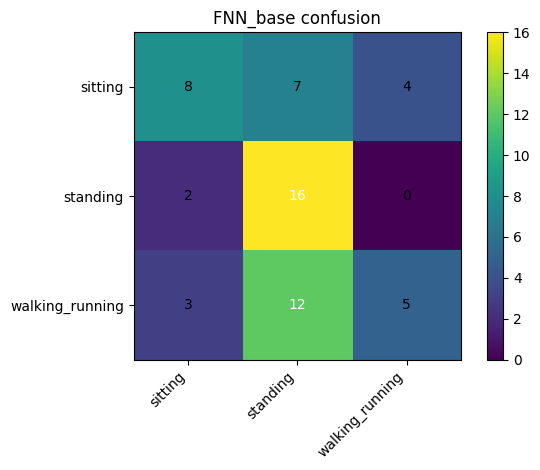

[CNN_base] ep 1/50 train_loss=1.1970 val_loss=1.1420 val_acc=0.3158
[CNN_base] ep 5/50 train_loss=0.8051 val_loss=1.1733 val_acc=0.2982
[CNN_base] ep 10/50 train_loss=0.6599 val_loss=1.3549 val_acc=0.2807
Early stopping at epoch 11
CNN_base 0.3508771929824561 0.3447993447993449
                 precision    recall  f1-score   support

        sitting       0.40      0.53      0.45        19
       standing       0.21      0.22      0.22        18
walking_running       0.46      0.30      0.36        20

       accuracy                           0.35        57
      macro avg       0.36      0.35      0.34        57
   weighted avg       0.36      0.35      0.35        57



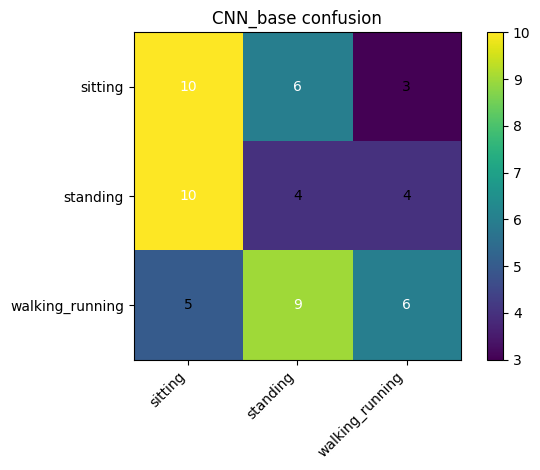

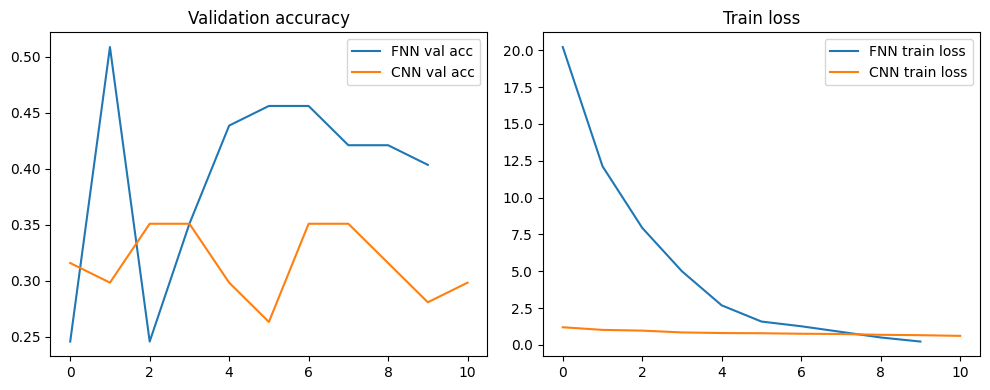

In [ ]:
# Subtask 1: compare a flat MLP (no spatial structure) vs a small CNN (local patterns)


class FNN_base(nn.Module):
    """MLP on flattened pixels: ignores 2D layout, so it is a weak baseline for photos."""

    def __init__(self, in_dim, num_classes=NUM_CLASSES):
        super().__init__()
        h = 512
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_dim, h),
            nn.ReLU(),
            nn.Linear(h, h),
            nn.ReLU(),
            nn.Linear(h, num_classes),
        )

    def forward(self, x):
        return self.net(x)


class CNN_base(nn.Module):
    """Small conv stack: local filters + pooling, then one linear layer for class logits."""

    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),  # 3 RGB channels -> 32 feature maps
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((4, 4)),  # fixed 4x4 spatial size before flatten
        )
        self.fc = nn.Linear(128 * 4 * 4, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # flatten batch of feature maps for the linear layer
        return self.fc(x)


in_dim = 3 * IMG_SIZE * IMG_SIZE  # C * H * W after resize (same tensor shape as CNN input)
fnn = FNN_base(in_dim)
fnn, hist_fnn = train_model(fnn, train_loader_base, val_loader_base, epochs=50, lr=1e-3, weight_decay=0.0, model_name="FNN_base")
res_fnn = evaluate_classifier(fnn, val_loader_base)
print("FNN_base", res_fnn["accuracy"], res_fnn["macro_f1"])
print(res_fnn["report"])
plot_confusion(res_fnn["confusion"], "FNN_base confusion")

cnn = CNN_base()
# Same data and training recipe as FNN, so differences come from architecture only
cnn, hist_cnn = train_model(cnn, train_loader_base, val_loader_base, epochs=50, lr=1e-3, weight_decay=0.0, model_name="CNN_base")
res_cnn = evaluate_classifier(cnn, val_loader_base)
print("CNN_base", res_cnn["accuracy"], res_cnn["macro_f1"])
print(res_cnn["report"])
plot_confusion(res_cnn["confusion"], "CNN_base confusion")

# Side-by-side learning curves: validation accuracy and training loss
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(hist_fnn["val_acc"], label="FNN val acc")
ax[0].plot(hist_cnn["val_acc"], label="CNN val acc")
ax[0].set_title("Validation accuracy")
ax[0].legend()
ax[1].plot(hist_fnn["train_loss"], label="FNN train loss")
ax[1].plot(hist_cnn["train_loss"], label="CNN train loss")
ax[1].set_title("Train loss")
ax[1].legend()
plt.tight_layout()
plt.show()

## Subtask 2 — `CNN_gen` (augmented data + regularization)

Augmentation on the **training** set only; **dropout**, **weight decay**, and **early stopping** (already in `train_model`).

In [ ]:
# Subtask 2: stronger training pipeline — random image transforms + dropout + weight decay
# (Augment only training data; validation stays on base_tf so metrics stay comparable.)

train_aug_tf = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),  # left/right mirror (often valid for people)
        transforms.RandomRotation(15),  # small viewpoint / camera tilt variation
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),  # lighting robustness
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

train_loader_gen = DataLoader(
    ImagePathDataset(train_paths, train_y, train_aug_tf),
    batch_size=32,
    shuffle=True,
    num_workers=0,
    generator=torch.Generator().manual_seed(SEED),
)


class CNN_gen(nn.Module):
    """Same conv backbone as CNN_base; dropout on the flat vector reduces overfitting."""

    def __init__(self, num_classes=NUM_CLASSES, p_drop=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.drop = nn.Dropout(p_drop)
        self.fc = nn.Linear(128 * 4 * 4, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.drop(x)  # randomly zero features during training only
        return self.fc(x)


cnn_gen = CNN_gen(p_drop=0.5)
# weight_decay adds L2 penalty in Adam; val_loader_base keeps evaluation identical to CNN_base
cnn_gen, hist_gen = train_model(
    cnn_gen,
    train_loader_gen,
    val_loader_base,
    epochs=60,
    lr=1e-3,
    weight_decay=1e-4,
    patience=10,
    model_name="CNN_gen",
)
res_gen = evaluate_classifier(cnn_gen, val_loader_base)
print("CNN_gen", res_gen["accuracy"], res_gen["macro_f1"])
print(res_gen["report"])
plot_confusion(res_gen["confusion"], "CNN_gen confusion")

# Compare best validation accuracy curves (same val set for both models)
plt.figure(figsize=(6, 4))
plt.plot(hist_cnn["val_acc"], label="CNN_base val acc")
plt.plot(hist_gen["val_acc"], label="CNN_gen val acc")
plt.legend()
plt.title("CNN_base vs CNN_gen validation accuracy")
plt.tight_layout()
plt.show()

[CNN_gen] ep 1/60 train_loss=1.2511 val_loss=1.1200 val_acc=0.3509
[CNN_gen] ep 5/60 train_loss=0.9900 val_loss=1.2603 val_acc=0.3509


## Subtask 3 — Transfer learning (Hugging Face), binary classifier

We use **two** action classes (configurable): default **`sitting` vs `standing`**.  
A small pretrained model (`microsoft/resnet-18`) is fine-tuned with a **binary** head.

## Subtask 4 — CLIP image embeddings + small classifier

Frozen **CLIP** image encoder; train a **linear** (or MLP) head on top of L2-normalized embeddings.

## Subtask 5 — CLIP text–image similarity features

Encode **prompts** for each class, take **cosine similarity** (dot product on L2-normalized vectors) between image and text embeddings → **logits** for argmax.  
Optionally compare to a small **linear classifier** on the concatenation `[image_emb || cosine_scores]`.

## Summary — results table (validation set)

Copy this table into the report; replace with the **exact** numbers after a full **Run All**.